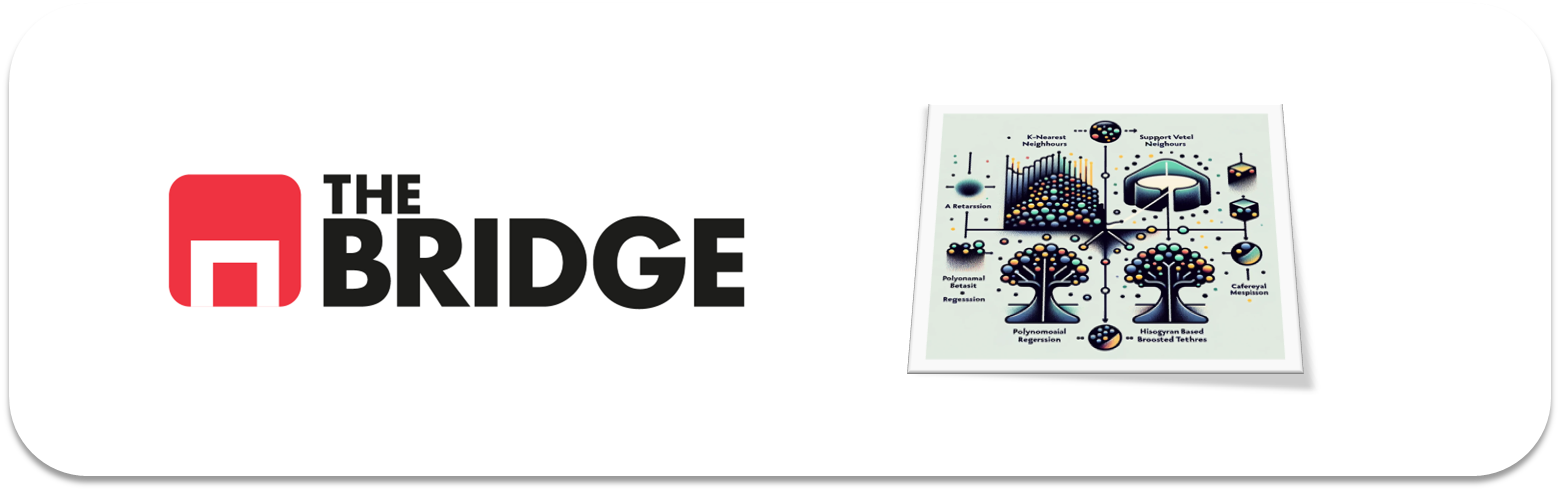

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caja de herramientas de visualizacion del bootcamp
import bootcampviztools as bt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, balanced_accuracy_score,
                             ConfusionMatrixDisplay)

# Para el balanceo de clases
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings("ignore")  # silenciamos avisos para una salida mas limpia

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
target = "SeriousDlqin2yrs"

df = pd.read_csv("./data/credit_npo.csv")
print("Dimensiones (filas, columnas):", df.shape)
df.head()

Dimensiones (filas, columnas): (12537, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

**Descripcion de las variables**

Este dataset es el conocido *"Give Me Some Credit"*. Cada fila es una persona y las columnas describen su situacion crediticia:

| Variable | Descripcion |
|---|---|
| `SeriousDlqin2yrs` | **(Target)** La persona tuvo una morosidad grave (90+ dias de retraso) en los 2 anos siguientes. 1 = si, 0 = no. |
| `RevolvingUtilizationOfUnsecuredLines` | Saldo usado en tarjetas y lineas de credito dividido por el limite total disponible (porcentaje de uso del credito). |
| `age` | Edad de la persona en anos. |
| `NumberOfTime30-59DaysPastDueNotWorse` | Numero de veces con 30-59 dias de retraso en los ultimos 2 anos. |
| `DebtRatio` | Cuota mensual de deudas + gastos divididos entre los ingresos mensuales. |
| `MonthlyIncome` | Ingresos mensuales. |
| `NumberOfOpenCreditLinesAndLoans` | Numero de prestamos y lineas de credito abiertas. |
| `NumberOfTimes90DaysLate` | Numero de veces con 90+ dias de retraso. |
| `NumberRealEstateLoansOrLines` | Numero de hipotecas y prestamos inmobiliarios. |
| `NumberOfTime60-89DaysPastDueNotWorse` | Numero de veces con 60-89 dias de retraso en los ultimos 2 anos. |
| `NumberOfDependents` | Numero de personas a cargo (sin contar la propia). |

**Clasificacion inicial de las variables**

Apoyandonos en el `info()` y en el numero de valores unicos, todas las columnas son numericas (no hay texto). Las dividimos asi:

- **Categorica:** `SeriousDlqin2yrs` es numerica por tipo pero conceptualmente es **categorica binaria** (es nuestro target, 0/1).
- **Numericas continuas:** `RevolvingUtilizationOfUnsecuredLines`, `age`, `DebtRatio`, `MonthlyIncome`.
- **Numericas discretas (conteos):** el resto (`NumberOfTime30-59...`, `NumberOfOpenCreditLinesAndLoans`, `NumberOfTimes90DaysLate`, `NumberRealEstateLoansOrLines`, `NumberOfTime60-89...`, `NumberOfDependents`). Son conteos enteros; los trataremos como numericas porque el orden y la magnitud tienen sentido para un KNN.

A efectos de modelado **todas las features son numericas**, asi que no necesitaremos codificacion (one-hot/ordinal), pero si escalado (importante para el KNN).

In [4]:
# Tipos, nulos y numero de valores unicos por columna
resumen = pd.DataFrame({
    "dtype": df.dtypes,
    "nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(2),
    "n_unicos": df.nunique()
})
resumen

,dtype,nulos,%_nulos,n_unicos
SeriousDlqin2yrs,int64,0,0.00,2
RevolvingUtilizationOfUnsecuredLines,float64,0,0.00,10764
age,int64,0,0.00,78
NumberOfTime30-59DaysPastDueNotWorse,int64,0,0.00,10
DebtRatio,float64,0,0.00,11547
MonthlyIncome,float64,721,5.75,4167
NumberOfOpenCreditLinesAndLoans,int64,0,0.00,43
NumberOfTimes90DaysLate,int64,0,0.00,13
NumberRealEstateLoansOrLines,int64,0,0.00,16
NumberOfTime60-89DaysPastDueNotWorse,int64,0,0.00,8


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,12537.0,0.068916,0.253321,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,12537.0,0.330359,0.368148,0.0,0.030651,0.163490,0.582219,6.0
age,12537.0,52.079445,15.077498,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,12537.0,0.409588,4.055787,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,12537.0,1.902253,9.122216,0.0,0.142268,0.302025,0.506725,99.0
MonthlyIncome,11816.0,6864.815420,11855.905437,0.0,3498.750000,5416.000000,8300.000000,702500.0
NumberOfOpenCreditLinesAndLoans,12537.0,8.482332,5.165422,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,12537.0,0.259312,4.035658,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,12537.0,0.999202,1.134325,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,12537.0,0.228364,4.018873,0.0,0.000000,0.000000,0.000000,98.0


Observamos un par de cosas importantes de cara al modelado:

- Hay **nulos** en `MonthlyIncome` (~5.8%) y `NumberOfDependents` (~1.4%). Habra que imputarlos.
- Hay **valores extremos** muy marcados (p.ej. `MonthlyIncome` llega a 702500, `DebtRatio` y `RevolvingUtilization` tienen colas largas). El KNN es sensible a la escala y a los outliers, asi que el escalado sera obligatorio.
- Las columnas de dias de retraso tienen un valor raro `98` que investigaremos en la fase de modelado.

Visualizamos las variables continuas con la caja de herramientas (`plot_combined_graphs`):

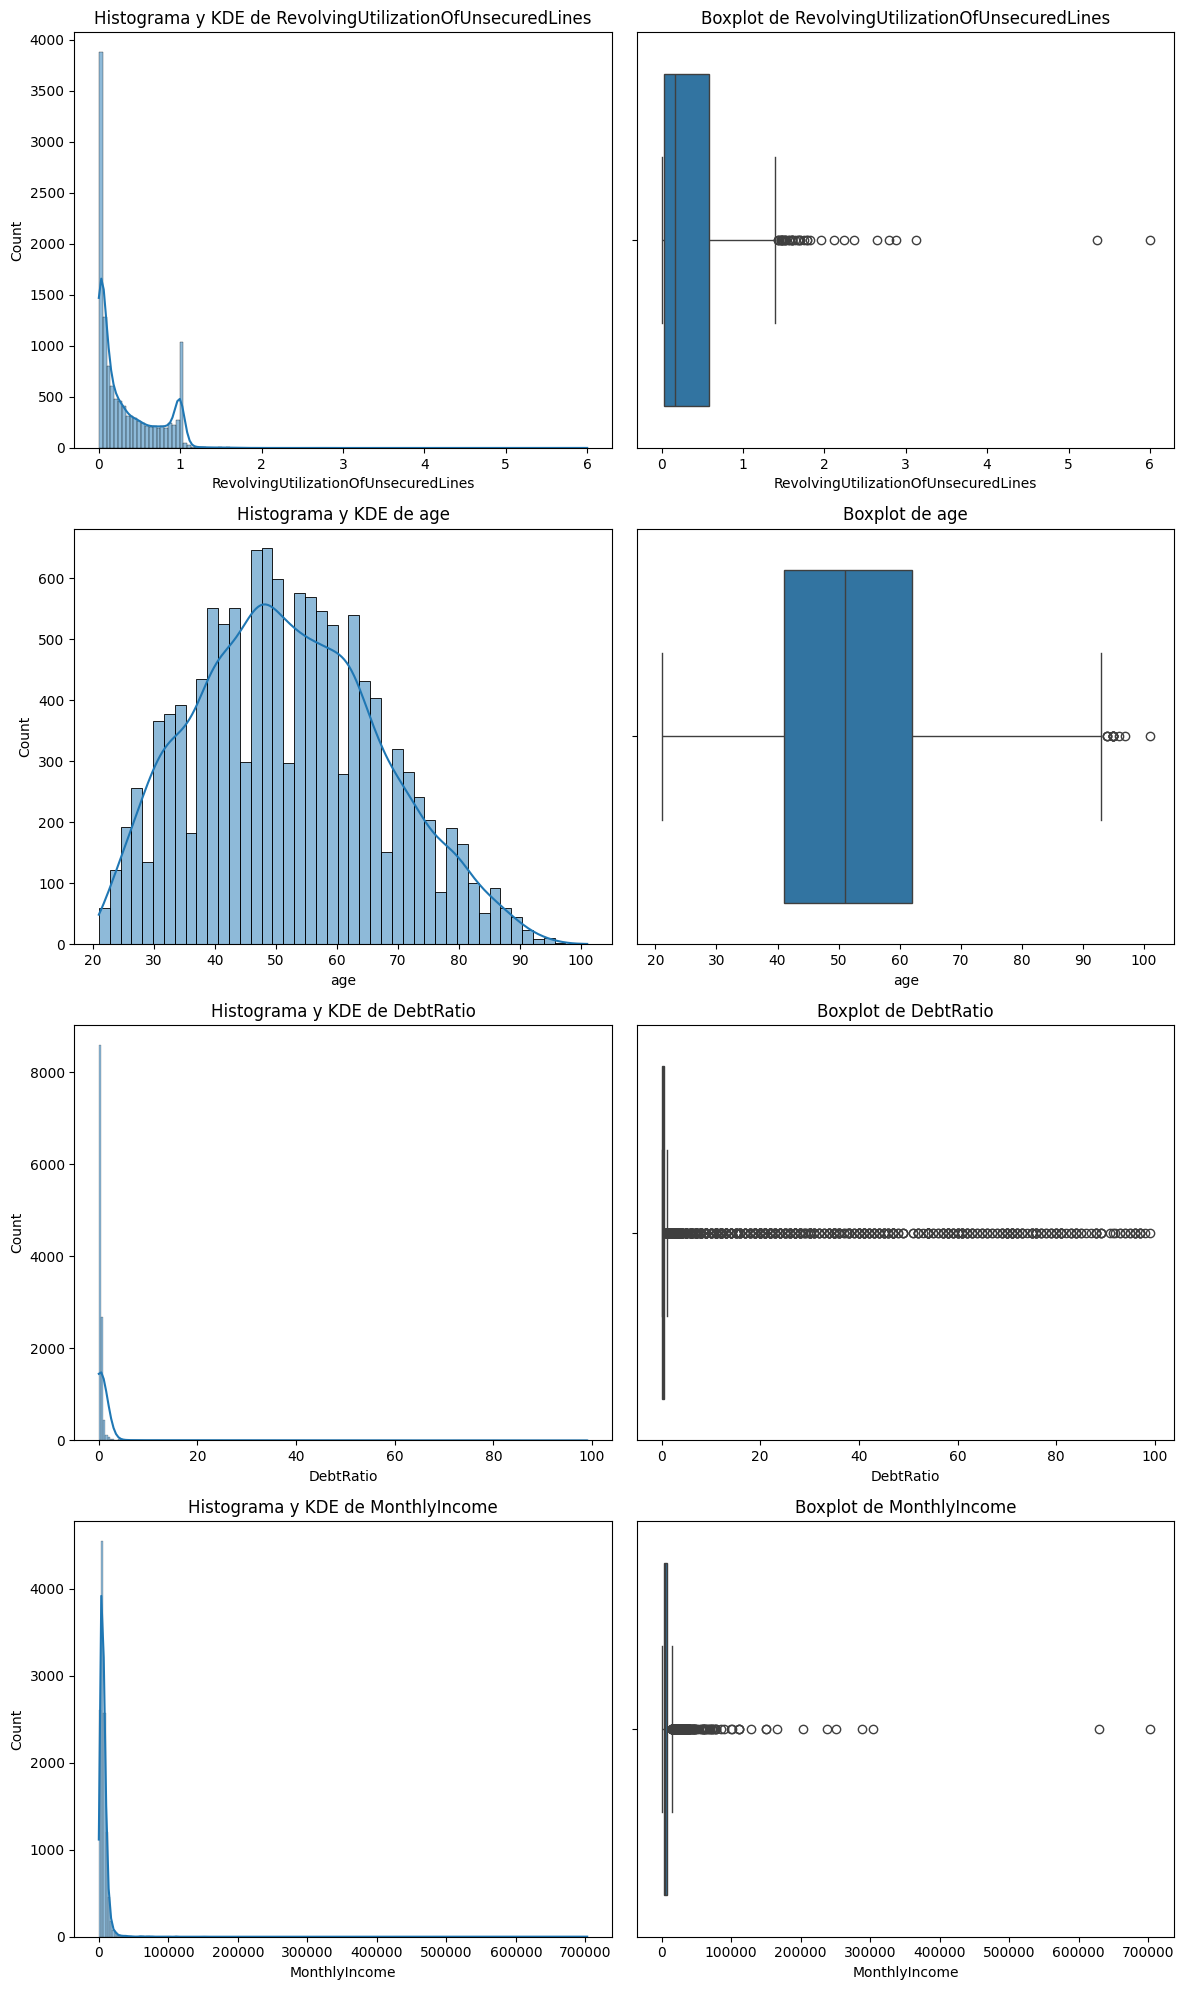

In [6]:
variables_continuas = ["RevolvingUtilizationOfUnsecuredLines", "age",
                       "DebtRatio", "MonthlyIncome"]
bt.plot_combined_graphs(df, variables_continuas)

Los histogramas confirman las colas largas: `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio` y `MonthlyIncome` estan muy concentradas cerca de cero con unos pocos valores enormes. `age` es la mas "normal" de todas. Esto refuerza la necesidad de escalar antes de aplicar KNN.

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Es un problema de **clasificacion supervisada binaria**: queremos predecir una etiqueta de dos clases (0 = la persona no entrara en morosidad grave, 1 = si lo hara) a partir de variables conocidas.

La **variable target es `SeriousDlqin2yrs`**.

### #1.3
Pinta la distribución de frecuencias del target y coméntala

SeriousDlqin2yrs
0    11673
1      864
Name: count, dtype: int64

SeriousDlqin2yrs
0    0.9311
1    0.0689
Name: proportion, dtype: float64


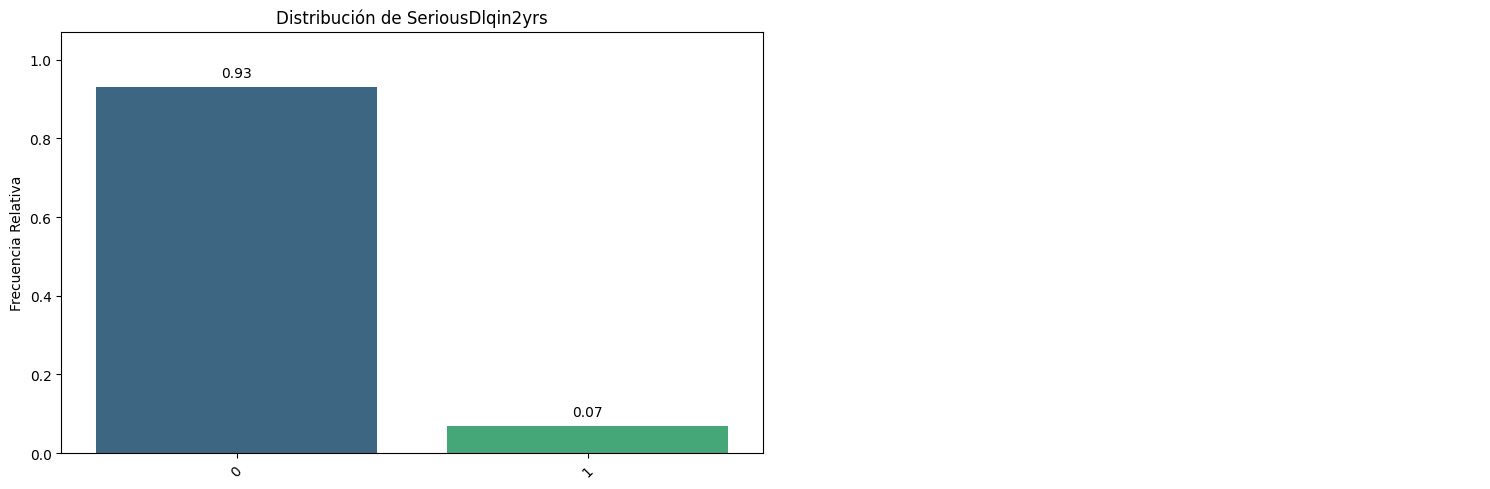

In [7]:
print(df[target].value_counts())
print()
print(df[target].value_counts(normalize=True).round(4))

bt.pinta_distribucion_categoricas(df, [target], relativa=True, mostrar_valores=True)

El target esta **muy desbalanceado**: solo un ~6.9% de las personas (864 de 12537) entran en morosidad grave (clase 1), frente al ~93.1% que no (clase 0).

Esto es clave: un modelo que prediga siempre "0" acertaria el 93% de las veces (*accuracy* enganosa), pero seria inutil porque no detectaria a nadie en dificultades, que es justo lo que nos interesa. Por eso:

1. **No usaremos *accuracy*** como metrica, sino el **recall medio** (la media del recall de las dos clases), que penaliza ignorar la clase minoritaria. En `sklearn` esto es `balanced_accuracy`.
2. Tendremos que aplicar **tecnicas de balanceo** (SMOTE, `class_weight`, ...) para ayudar al modelo con la clase minoritaria.

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

**Plan de trabajo**

1. **Preparacion:** limpiar el valor centinela `98`, separar X/y y hacer el split train/test (estratificado por el desbalanceo).
2. **Pipelines:** imputacion de nulos + escalado + modelo, todo dentro de un `Pipeline` para que la validacion cruzada sea honesta (sin fugas de informacion).
3. **Comparacion por validacion cruzada** de 3 modelos (KNN, Regresion Logistica y Random Forest), primero **sin balanceo** y luego **con balanceo**, usando `balanced_accuracy`.
4. **Optimizacion de hiperparametros** del mejor modelo (y tambien del KNN, que es el protagonista de la unidad) con `GridSearchCV`.
5. **Evaluacion final** sobre test + **analisis de errores**.

### 2.1 Preparacion de los datos

In [8]:
# Las columnas de "dias de retraso" contienen el valor 98, que es un codigo
# centinela (dato perdido/erroneo) tipico de este dataset. Aparece exactamente
# en las mismas 21 filas de las tres columnas. Lo convertimos a NaN para
# imputarlo despues junto con el resto de nulos.
columnas_retraso = ["NumberOfTime30-59DaysPastDueNotWorse",
                    "NumberOfTimes90DaysLate",
                    "NumberOfTime60-89DaysPastDueNotWorse"]
print("Filas con el centinela 98 antes de limpiar:",
      (df[columnas_retraso] == 98).any(axis=1).sum())

df[columnas_retraso] = df[columnas_retraso].replace(98, np.nan)

# Separamos features (X) y target (y)
X = df.drop(columns=target)
y = df[target]
print("X:", X.shape, " y:", y.shape)

Filas con el centinela 98 antes de limpiar: 21
X: (12537, 10)  y: (12537,)


In [9]:
# Split estratificado: mantiene la misma proporcion de clases en train y test,
# algo importante cuando el target esta desbalanceado.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Proporcion de clase 1 en train:", round(y_train.mean(), 4))
print("Proporcion de clase 1 en test: ", round(y_test.mean(), 4))

Train: (10029, 10)  Test: (2508, 10)
Proporcion de clase 1 en train: 0.0689
Proporcion de clase 1 en test:  0.069


### 2.2 Pipelines de preprocesado + modelo

Metemos la imputacion (mediana) y el escalado dentro de un `Pipeline` junto con el modelo. Asi, en la validacion cruzada, el escalador y el imputador se ajustan **solo con el train de cada fold**, evitando fugas de informacion. Cuando ademas queramos balancear, usaremos el `Pipeline` de `imbalanced-learn` para meter SMOTE (que solo debe aplicarse al train).

In [10]:
def crea_pipeline(modelo, balanceo=None):
    """Devuelve un pipeline: imputacion (mediana) + escalado + (SMOTE opcional) + modelo.

    - balanceo=None  -> Pipeline normal de sklearn.
    - balanceo='smote' -> Pipeline de imblearn con SMOTE antes del modelo.
    """
    pasos = [("imputador", SimpleImputer(strategy="median")),
             ("escalador", StandardScaler())]
    if balanceo == "smote":
        pasos.append(("smote", SMOTE(random_state=42)))
        pasos.append(("modelo", modelo))
        return ImbPipeline(pasos)
    pasos.append(("modelo", modelo))
    return Pipeline(pasos)

### 2.3 Comparacion de modelos por validacion cruzada (sin balanceo)

Comparamos los 3 modelos tal cual, con `balanced_accuracy` (= recall medio) y validacion cruzada de 5 folds sobre el train.

In [11]:
modelos_base = {
    "KNN": crea_pipeline(KNeighborsClassifier()),
    "Regresion Logistica": crea_pipeline(LogisticRegression(max_iter=5000)),
    "Random Forest": crea_pipeline(RandomForestClassifier(random_state=42)),
}

print("balanced_accuracy (recall medio) - validacion cruzada 5 folds\n")
for nombre, pipe in modelos_base.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5,
                             scoring="balanced_accuracy")
    print(f"{nombre:22s}: {scores.mean():.3f} +/- {scores.std():.3f}")

balanced_accuracy (recall medio) - validacion cruzada 5 folds



KNN                   : 0.580 +/- 0.007
Regresion Logistica   : 0.578 +/- 0.009


Random Forest         : 0.580 +/- 0.015


Los tres modelos rondan un pobre **~0.58** de recall medio. Como sospechabamos, sin balancear se dedican casi solo a predecir la clase mayoritaria (aciertan los "0" pero se les escapan los "1"). Hay que balancear.

### 2.4 Comparacion de modelos por validacion cruzada (con balanceo)

Ahora aplicamos balanceo. Para el KNN usamos **SMOTE** (no tiene `class_weight`); para Regresion Logistica y Random Forest usamos `class_weight="balanced"`, que pesa mas los errores en la clase minoritaria.

In [12]:
modelos_bal = {
    "KNN + SMOTE":
        crea_pipeline(KNeighborsClassifier(), balanceo="smote"),
    "Regresion Logistica (balanced)":
        crea_pipeline(LogisticRegression(max_iter=5000, class_weight="balanced")),
    "Random Forest (balanced)":
        crea_pipeline(RandomForestClassifier(random_state=42, class_weight="balanced")),
}

print("balanced_accuracy (recall medio) - validacion cruzada 5 folds\n")
for nombre, pipe in modelos_bal.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5,
                             scoring="balanced_accuracy")
    print(f"{nombre:32s}: {scores.mean():.3f} +/- {scores.std():.3f}")

balanced_accuracy (recall medio) - validacion cruzada 5 folds



KNN + SMOTE                     : 0.701 +/- 0.015
Regresion Logistica (balanced)  : 0.775 +/- 0.022


Random Forest (balanced)        : 0.562 +/- 0.017


El balanceo cambia el panorama por completo:

- **Regresion Logistica (balanced) ~0.78** -> el mejor.
- **KNN + SMOTE ~0.70** -> sube muchisimo respecto a antes; segundo mejor.
- **Random Forest (balanced) ~0.56** -> el `class_weight` no le ayuda apenas en este caso (con SMOTE mejora algo, pero sigue por detras).

El **mejor modelo es la Regresion Logistica con `class_weight="balanced"`**. La afinaremos a continuacion. Como la unidad gira en torno al KNN, tambien lo optimizaremos para ver hasta donde llega.

### 2.5 Optimizacion de hiperparametros

**Mejor modelo: Regresion Logistica.** Ajustamos su parametro de regularizacion `C` con `GridSearchCV`.

In [13]:
pipe_lr = crea_pipeline(LogisticRegression(max_iter=5000, class_weight="balanced"))
param_grid_lr = {"modelo__C": [0.01, 0.1, 1, 10]}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring="balanced_accuracy")
grid_lr.fit(X_train, y_train)

print("Mejor C:", grid_lr.best_params_)
print("Mejor balanced_accuracy (CV):", round(grid_lr.best_score_, 3))

Mejor C: {'modelo__C': 0.1}
Mejor balanced_accuracy (CV): 0.777


**KNN (protagonista de la unidad).** Siguiendo el estilo de los ejercicios, primero hacemos un barrido manual de `k` con validacion cruzada y lo dibujamos; luego una busqueda completa con `GridSearchCV` sobre `k` y `weights`.

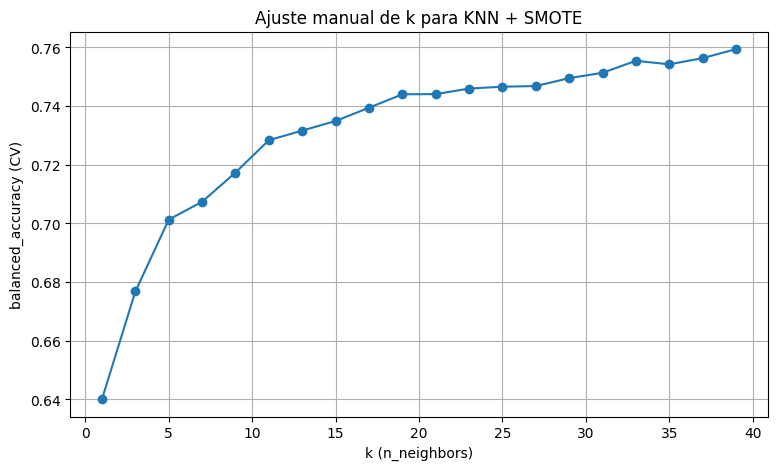

Mejor k: 39 -> balanced_accuracy: 0.759


In [14]:
# Barrido manual de k (con SMOTE), midiendo balanced_accuracy por CV
ks = list(range(1, 41, 2))
medias = []
for k in ks:
    pipe_k = crea_pipeline(KNeighborsClassifier(n_neighbors=k), balanceo="smote")
    s = cross_val_score(pipe_k, X_train, y_train, cv=5, scoring="balanced_accuracy")
    medias.append(s.mean())

plt.figure(figsize=(9, 5))
plt.plot(ks, medias, marker="o")
plt.xlabel("k (n_neighbors)")
plt.ylabel("balanced_accuracy (CV)")
plt.title("Ajuste manual de k para KNN + SMOTE")
plt.grid(True)
plt.show()

mejor_k = ks[int(np.argmax(medias))]
print("Mejor k:", mejor_k, "-> balanced_accuracy:", round(max(medias), 3))

In [15]:
# Busqueda completa de k y weights con GridSearchCV
pipe_knn = crea_pipeline(KNeighborsClassifier(), balanceo="smote")
param_grid_knn = {"modelo__n_neighbors": [11, 21, 31, 41],
                  "modelo__weights": ["uniform", "distance"]}

grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring="balanced_accuracy")
grid_knn.fit(X_train, y_train)

print("Mejor combinacion KNN:", grid_knn.best_params_)
print("Mejor balanced_accuracy (CV):", round(grid_knn.best_score_, 3))

Mejor combinacion KNN: {'modelo__n_neighbors': 41, 'modelo__weights': 'uniform'}
Mejor balanced_accuracy (CV): 0.761


El KNN afinado llega a ~0.76, muy cerca pero todavia por debajo de la Regresion Logistica (~0.78). Asi que nuestro **modelo final es la Regresion Logistica optimizada**.

### 2.6 Evaluacion final sobre test

Evaluamos el mejor modelo (ya reentrenado con todo el train por `GridSearchCV`) contra el conjunto de **test**, que no ha visto en ningun momento.

In [16]:
modelo_final = grid_lr.best_estimator_
y_pred = modelo_final.predict(X_test)

print(classification_report(y_test, y_pred))
print("Balanced accuracy (recall medio) en test:",
      round(balanced_accuracy_score(y_test, y_pred), 3))

              precision    recall  f1-score   support

           0       0.98      0.81      0.88      2335
           1       0.22      0.73      0.33       173

    accuracy                           0.80      2508
   macro avg       0.60      0.77      0.61      2508
weighted avg       0.92      0.80      0.84      2508

Balanced accuracy (recall medio) en test: 0.767


En test obtenemos un **recall medio de ~0.77**, coherente con lo visto en validacion cruzada (no hay sobreajuste). Leyendo el `classification_report`:

- **Clase 1 (morosidad):** recall ~0.73 -> detectamos casi 3 de cada 4 personas que entraran en dificultades. Su precision es baja (~0.22), es decir, damos bastantes falsas alarmas.
- **Clase 0 (sin morosidad):** recall ~0.81, precision muy alta (~0.98).

Es justo el compromiso que buscabamos: sacrificamos precision en la clase positiva para **capturar a la mayoria de las personas en riesgo**, que es lo valioso en un problema de credito (es mas caro no detectar a alguien que va a impagar que revisar de mas a alguien que estaba bien).

### 2.7 Analisis de errores

Miramos la matriz de confusion normalizada de dos formas: por fila (recall, "de cada clase real, que porcentaje acierto") y por columna (precision, "cuando predigo una clase, cuanto acierto").

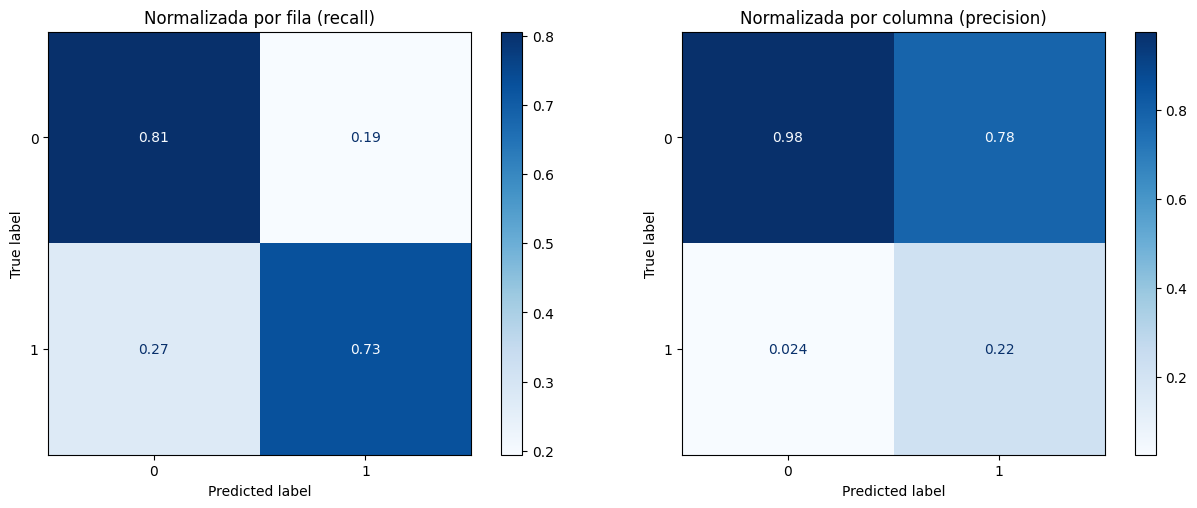

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="true", cmap="Blues", ax=axes[0])
axes[0].set_title("Normalizada por fila (recall)")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="pred", cmap="Blues", ax=axes[1])
axes[1].set_title("Normalizada por columna (precision)")

plt.tight_layout()
plt.show()

- **Por fila (recall):** de las personas que SI entran en morosidad (fila 1) capturamos ~73% y se nos escapa ~27% (falsos negativos). De las que no (fila 0) acertamos ~81%.
- **Por columna (precision):** cuando el modelo dice "clase 1" acierta poco (~22%); la mayoria de sus alarmas son falsas. Esto vuelve a reflejar el compromiso: priorizamos no dejar pasar morosos a costa de muchas falsas alarmas.

Veamos como son las personas en dificultades que **no detectamos** (falsos negativos) frente a las que **si** (verdaderos positivos), para entender por donde falla el modelo:

In [18]:
resultados = X_test.copy()
resultados["real"] = y_test.values
resultados["pred"] = y_pred

cols_interes = ["RevolvingUtilizationOfUnsecuredLines", "age",
                "DebtRatio", "MonthlyIncome", "NumberOfTimes90DaysLate"]

fn = resultados[(resultados["real"] == 1) & (resultados["pred"] == 0)]  # no detectados
tp = resultados[(resultados["real"] == 1) & (resultados["pred"] == 1)]  # detectados

comparativa = pd.DataFrame({
    "Falsos negativos (no detectados)": fn[cols_interes].median(),
    "Verdaderos positivos (detectados)": tp[cols_interes].median(),
})
print("Numero de falsos negativos:", len(fn), "| verdaderos positivos:", len(tp))
comparativa.round(2)

Numero de falsos negativos: 47 | verdaderos positivos: 126


,Falsos negativos (no detectados),Verdaderos positivos (detectados)
RevolvingUtilizationOfUnsecuredLines,0.18,0.97
age,48.00,44.00
DebtRatio,0.23,0.31
MonthlyIncome,6600.00,4466.00
NumberOfTimes90DaysLate,0.00,0.00


Los **falsos negativos** (morosos que se nos escapan) tienen un `RevolvingUtilizationOfUnsecuredLines` mediano mucho mas bajo (~0.18 frente a ~0.97 de los detectados) y un `DebtRatio` algo menor: son personas que "parecen sanas" segun sus features (apenas usan su credito disponible), por eso el modelo no las marca, aunque acabaron en morosidad.

**Posibles mejoras** (en linea con lo visto en el workout de analisis de errores):
- **Ingenieria de features:** crear variables que combinen los distintos retrasos o ratios de ingresos/deuda.
- **Modelos mas potentes / ensamblado:** probar Gradient Boosting (CatBoost/XGBoost) o ensamblar un segundo modelo centrado en separar mejor la clase 1.
- **Ajustar el umbral de decision** segun el coste real (que dira Negocio) de un falso negativo frente a un falso positivo.

## Conclusiones

- El problema es de **clasificacion binaria muy desbalanceada** (~6.9% de morosos), asi que la metrica adecuada es el **recall medio** (`balanced_accuracy`), no la *accuracy*.
- Sin balanceo, los modelos rinden fatal (~0.58). El **balanceo es lo que mas mejora** los resultados.
- Comparando 3 modelos por validacion cruzada, el mejor fue la **Regresion Logistica con `class_weight="balanced"`** (~0.78), por delante de **KNN + SMOTE** (~0.70-0.76 tras afinar) y de Random Forest.
- El modelo final logra **~0.77 de recall medio en test**, detectando ~73% de las personas en dificultades, a costa de bastantes falsas alarmas: un compromiso razonable para un caso de riesgo crediticio.